# Bolum 5: Matplotlib ile Gorsellestirme

Gercek veri uzerinde 5 farkli grafik olusturacagiz:
1. Bar Chart — Ulkelere gore satis
2. Line Chart — Aylik satis trendi
3. Pie Chart — Kategori dagilimi
4. Subplot — Urun + Musteri karsilastirma
5. Multi-line — Kategori bazli trend

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="1234"
)

## Verileri hazirlayalim

In [2]:
df_orders = pd.read_sql("""
    SELECT
        o.order_id,
        c.company_name AS musteri,
        c.country AS ulke,
        cat.category_name AS kategori,
        p.product_name AS urun,
        od.unit_price AS fiyat,
        od.quantity AS miktar,
        (od.unit_price * od.quantity) AS toplam,
        o.order_date AS tarih
    FROM orders o
    JOIN order_details od ON o.order_id = od.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN products p ON p.product_id = od.product_id
    JOIN categories cat ON cat.category_id = p.category_id
""", conn)

df_aylik = pd.read_sql("""
    SELECT
        DATE_TRUNC('month', o.order_date) AS ay,
        ROUND(SUM(od.unit_price * od.quantity)::numeric, 2) AS toplam_satis
    FROM orders o
    JOIN order_details od ON o.order_id = od.order_id
    GROUP BY ay
    ORDER BY ay
""", conn)
df_aylik['ay'] = pd.to_datetime(df_aylik['ay'], utc=True).dt.tz_localize(None)


ulke_satis = df_orders.groupby('ulke')['toplam'].sum().sort_values(ascending=False)
kategori_toplam = df_orders.groupby('kategori')['toplam'].sum()

print("Veriler hazir!")

Veriler hazir!


/var/folders/_7/4xlcmys94rvbr77bgf94cd180000gn/T/ipykernel_64668/6714496.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders = pd.read_sql("""
/var/folders/_7/4xlcmys94rvbr77bgf94cd180000gn/T/ipykernel_64668/6714496.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_aylik = pd.read_sql("""


## Grafik 1: Ulkelere Gore Satis (Bar Chart)

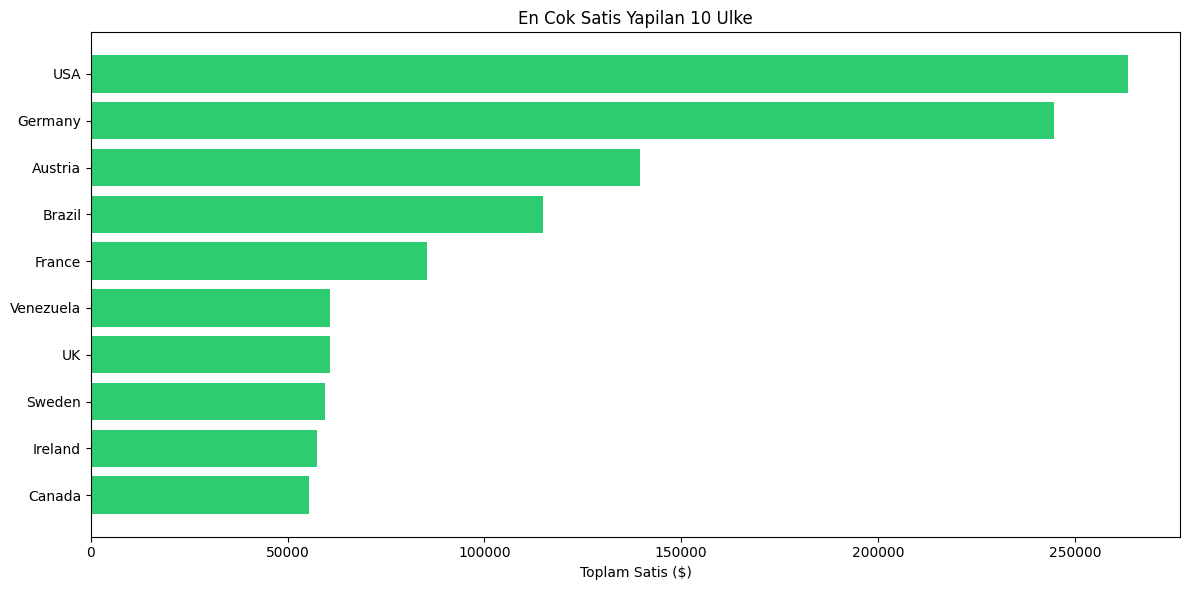

In [3]:
top10_ulke = ulke_satis.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10_ulke.index[::-1], top10_ulke.values[::-1], color='#2ecc71')
plt.xlabel('Toplam Satis ($)')
plt.title('En Cok Satis Yapilan 10 Ulke')
plt.tight_layout()
plt.show()

## Grafik 2: Aylik Satis Trendi (Line Chart)
Bu grafikte anomali var mi? Ani dusus/yukselis nerede?

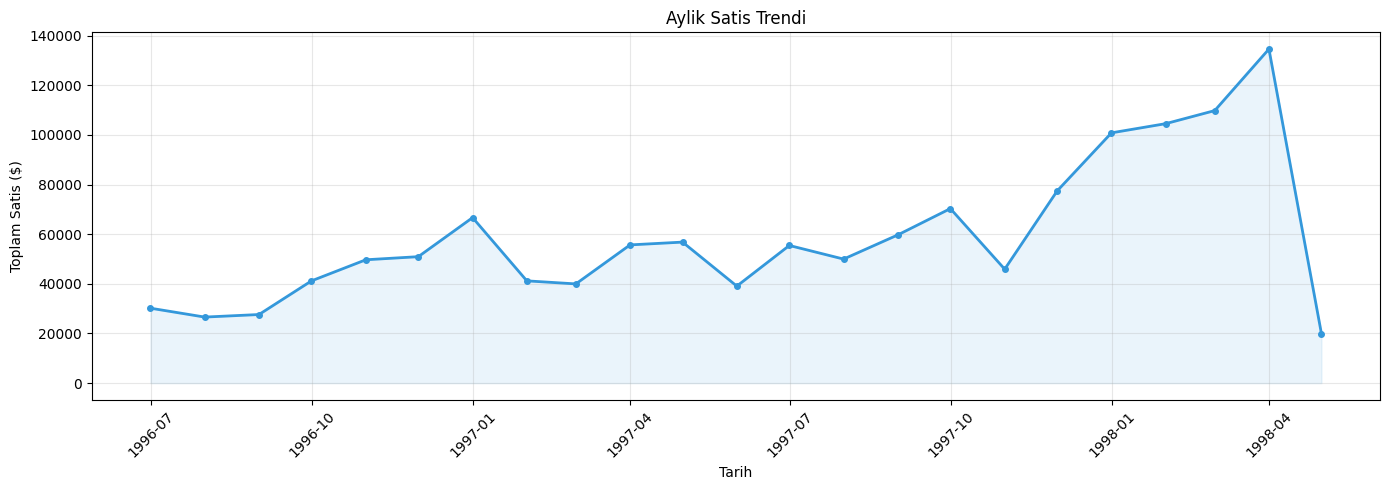

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df_aylik['ay'], df_aylik['toplam_satis'],
         marker='o', color='#3498db', linewidth=2, markersize=4)
plt.fill_between(df_aylik['ay'], df_aylik['toplam_satis'],
                 alpha=0.1, color='#3498db')
plt.title('Aylik Satis Trendi')
plt.xlabel('Tarih')
plt.ylabel('Toplam Satis ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Grafik 3: Kategorilere Gore Satis Dagilimi (Pie Chart)

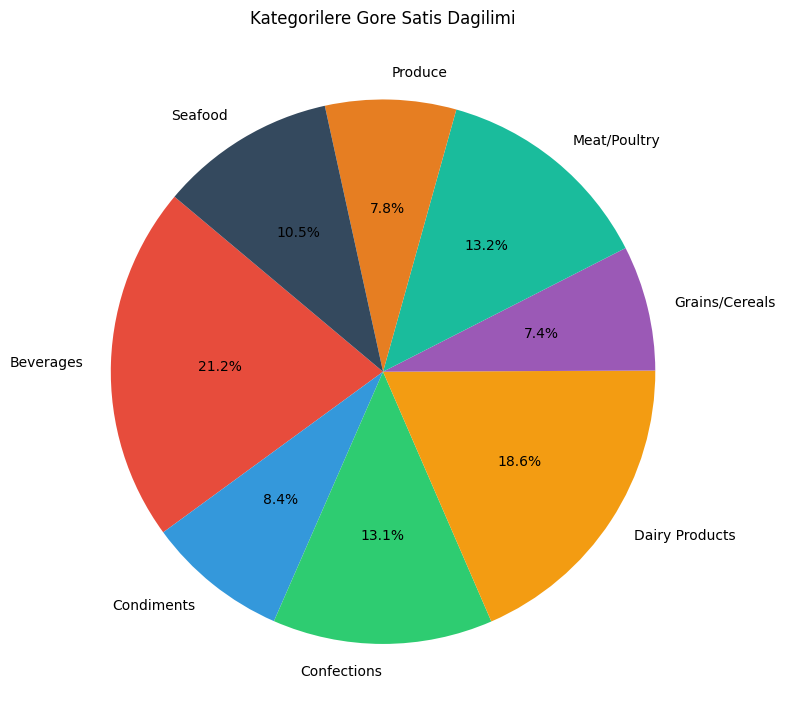

In [5]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

plt.figure(figsize=(8, 8))
plt.pie(kategori_toplam, labels=kategori_toplam.index,
        autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Kategorilere Gore Satis Dagilimi')
plt.tight_layout()
plt.show()

## Grafik 4: En Cok Satan Urunler + En Cok Harcayan Musteriler (Subplot)

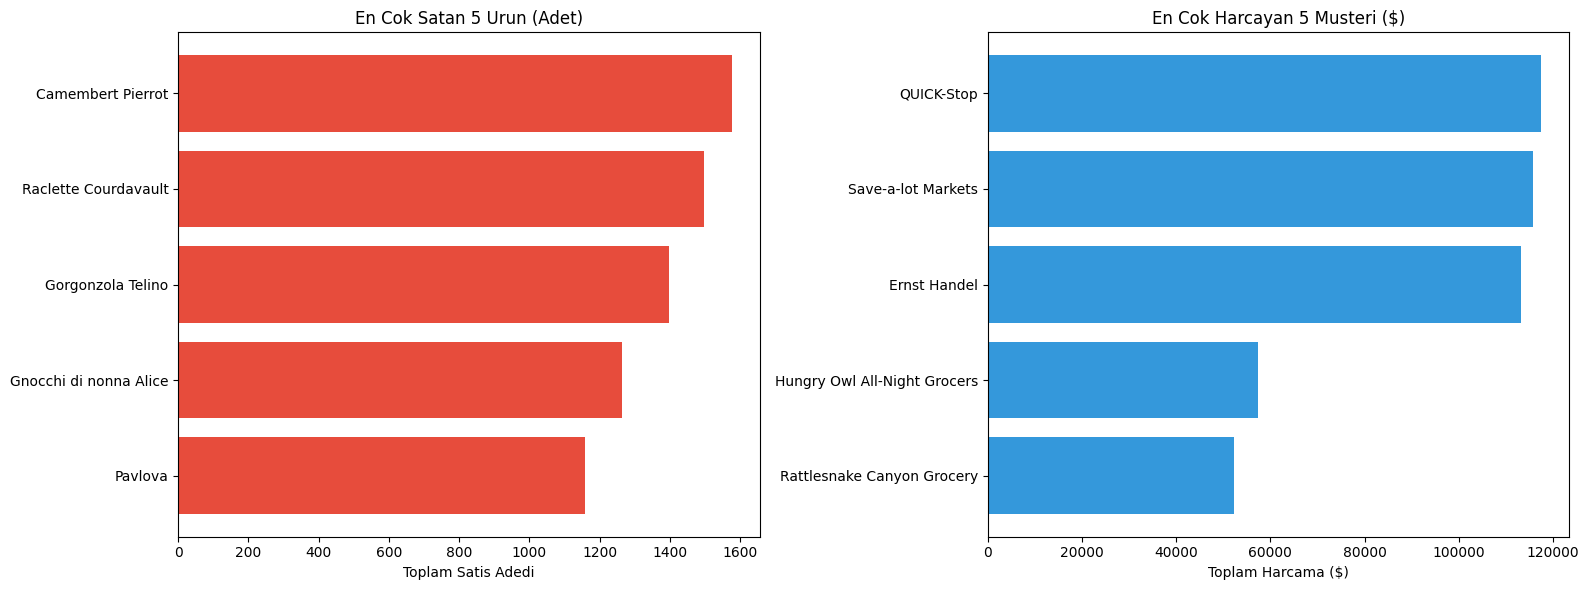

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: En cok satan 5 urun (adet)
top5_urun = df_orders.groupby('urun')['miktar'].sum().sort_values(ascending=False).head(5)
axes[0].barh(top5_urun.index[::-1], top5_urun.values[::-1], color='#e74c3c')
axes[0].set_title('En Cok Satan 5 Urun (Adet)')
axes[0].set_xlabel('Toplam Satis Adedi')

# Sag: En cok harcayan 5 musteri ($)
top5_musteri = df_orders.groupby('musteri')['toplam'].sum().sort_values(ascending=False).head(5)
axes[1].barh(top5_musteri.index[::-1], top5_musteri.values[::-1], color='#3498db')
axes[1].set_title('En Cok Harcayan 5 Musteri ($)')
axes[1].set_xlabel('Toplam Harcama ($)')

plt.tight_layout()
plt.show()

## Grafik 5: Kategori Bazli Aylik Trend (Ileri Seviye)
En cok satan 3 kategorinin zaman icindeki degisimi

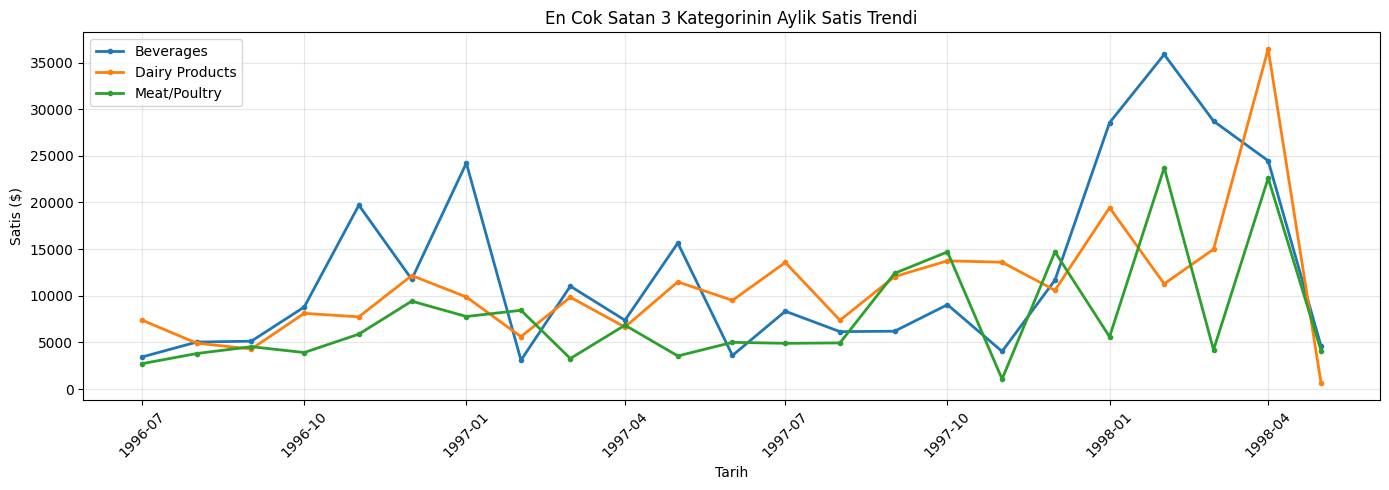

In [7]:
df_orders['tarih'] = pd.to_datetime(df_orders['tarih'])
df_orders['ay'] = df_orders['tarih'].dt.to_period('M').dt.to_timestamp()

top3_kat = kategori_toplam.sort_values(ascending=False).head(3).index.tolist()
df_top3 = df_orders[df_orders['kategori'].isin(top3_kat)]
pivot = df_top3.groupby(['ay', 'kategori'])['toplam'].sum().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
for kat in top3_kat:
    if kat in pivot.columns:
        plt.plot(pivot.index, pivot[kat], marker='o', linewidth=2, markersize=3, label=kat)

plt.title('En Cok Satan 3 Kategorinin Aylik Satis Trendi')
plt.xlabel('Tarih')
plt.ylabel('Satis ($)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()